In [2]:
# Import the main Libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# EDA Sales Data

In [3]:
# Load data and and print first 5 sample

df_sales = pd.read_json('Data/Raw_data/Sales.json')
df_sales.head()

,ProductKey,Product Name,Brand,Color,Subcategory,Category,CustomerKey,Customer Code,Name,Education,Occupation,Continent,City,State,CountryRegion,OrderDate,Quantity,Net Price
0,2492,Cigarette Lighter Adapter for Contoso Phones E...,Contoso,Cell phones Accessories,Cell phones Accessories,Cell phones,18813,CS551,None,None,None,North America,Spokane,Washington,United States,1/1/2008,1,23.7405
1,2492,Cigarette Lighter Adapter for Contoso Phones E...,Contoso,Cell phones Accessories,Cell phones Accessories,Cell phones,18813,CS551,None,None,None,North America,Spokane,Washington,United States,1/1/2008,1,23.7405
2,2492,Cigarette Lighter Adapter for Contoso Phones E...,Contoso,Cell phones Accessories,Cell phones Accessories,Cell phones,18813,CS551,None,None,None,North America,Spokane,Washington,United States,1/1/2008,1,23.7405
3,2492,Cigarette Lighter Adapter for Contoso Phones E...,Contoso,Cell phones Accessories,Cell phones Accessories,Cell phones,18813,CS551,None,None,None,North America,Spokane,Washington,United States,1/1/2008,1,23.7405
4,2492,Cigarette Lighter Adapter for Contoso Phones E...,Contoso,Cell phones Accessories,Cell phones Accessories,Cell phones,18813,CS551,None,None,None,North America,Spokane,Washington,United States,1/1/2008,1,23.7405


In [4]:
# print shape of data
df_sales.shape

(298246, 18)

In [29]:
# Display random answer

df_sales.sample(1).iloc[0]

ProductKey                                     1761
Product Name     MGS Combat Flight Simulator 2 M400
Brand                                 Tailspin Toys
Color                                Download Games
Subcategory                          Download Games
Category                             Games and Toys
CustomerKey                                   17565
Customer Code                                 28564
Name                                   Deng, Alisha
Education                           Partial College
Occupation                                 Clerical
Continent                                    Europe
City                                      Frankfurt
State                                         Hesse
CountryRegion                               Germany
OrderDate                                 1/17/2008
Quantity                                          1
Net Price                                    58.712
Name: 4551, dtype: object

In [6]:
# Print the general information of the data frame 
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 298246 entries, 0 to 298245
Data columns (total 18 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   ProductKey     298246 non-null  int64  
 1   Product Name   298246 non-null  object 
 2   Brand          298246 non-null  object 
 3   Color          298246 non-null  object 
 4   Subcategory    298246 non-null  object 
 5   Category       298246 non-null  object 
 6   CustomerKey    298246 non-null  int64  
 7   Customer Code  298246 non-null  object 
 8   Name           29797 non-null   object 
 9   Education      29797 non-null   object 
 10  Occupation     29797 non-null   object 
 11  Continent      298246 non-null  object 
 12  City           298246 non-null  object 
 13  State          298246 non-null  object 
 14  CountryRegion  298246 non-null  object 
 15  OrderDate      298246 non-null  object 
 16  Quantity       298246 non-null  int64  
 17  Net Price      298246 non-nul

# `This is a brief EDA. For a more detailed analysis, please refer to the documentation.`

## Dataset Overview
- Total Rows: 298,246  
- Total Columns: 18  
- Some column names are inconsistent and should be standardized for better readability and usability.
- **`OrderDate`** is currently of type **`object`**
- Extract from OrderDate: Year , Month , Day , Quarter
- Columns with Missing Data [Name , Education , Occupation]
- Feature Engineering **-->** create new columns called **`SalesAmount`** = **`Quantity`**  * **`Net Price`**


In [70]:
# Get stats for the numerical column
df_sales.select_dtypes(exclude="object").describe()

,ProductKey,CustomerKey,Quantity,Net Price
count,298246.000000,298246.000000,298246.000000,298246.000000
mean,1521.765459,18028.134758,1.399338,200.355684
std,795.349596,3245.803039,0.878602,331.377334
min,1.000000,13.000000,1.000000,0.760000
25%,822.000000,18857.000000,1.000000,14.400000
50%,1666.000000,18934.000000,1.000000,85.491000
75%,2321.000000,19018.000000,1.000000,255.550000
max,2517.000000,19143.000000,4.000000,3199.990000


In [72]:
# Check to unlogical values
# Unique values for each numerical feature
df_sales["Quantity"].unique()

array([1, 2, 3, 4], dtype=int64)

In [10]:
## Unique values and value counts for each categorical feature 
for i in df_sales.select_dtypes(include=["object"]).columns.tolist():
    print(f"( column_name : {i} )".center(80, " "))
    print("-------------".center(80, " "))
    print(df_sales[i].value_counts(), "\n")
    print("*" * 66)

                         ( column_name : Product Name )                         
                                 -------------                                  
Product Name
Contoso Original K1m Li-Ion Standard Battery E170 Black    3455
Cigarette Lighter Adapter for Contoso Phones E110 Black    3383
Contoso Touch Stylus Pen E150 Red                          3229
Contoso Rubberized Skin BlackBerry E100 White              3136
Headphone Adapter for Contoso Phone E130 White             3073
                                                           ... 
Contoso Wireless Notebook Optical Mouse X205 Blue             6
Contoso Telephoto Conversion Lens X400 Silver                 6
Litware Washer & Dryer 27in L420 Green                        6
Litware Home Theater System 7.1 Channel X711 Brown            6
Litware Washer & Dryer 27in L420 White                        5
Name: count, Length: 2495, dtype: int64 

******************************************************************
            

# `This is a brief EDA. For a more detailed analysis, please refer to the documentation.`
- Product Name column is `Structured Product` [ **Name Brand** + **Product Description** + **Product Code** + **Color** ]
- The values in the color column were incorrect, showing brand names instead. Corrected this by extracting the actual colors directly from the product names
- Ckeck Consistency between Category & Subcategory
- some value in Customer Code without prefix
- Adjusted name formatting for dashboard compatibility: Transformed the original `Last Name + First Name` structure into a standard `Last Name + First Name`
- Convert OrderDate into datetime

In [78]:
# Check Nall
# Missing Values Percentage by Column (%)
(df_sales.isna().sum() / len(df_sales)) * 100

ProductKey        0.000000
Product Name      0.000000
Brand             0.000000
Color             0.000000
Subcategory       0.000000
Category          0.000000
CustomerKey       0.000000
Customer Code     0.000000
Name             90.009254
Education        90.009254
Occupation       90.009254
Continent         0.000000
City              0.000000
State             0.000000
CountryRegion     0.000000
OrderDate         0.000000
Quantity          0.000000
Net Price         0.000000
dtype: float64

In [46]:
# Check number of Nall for each columns
df_sales.isna().sum().loc[df_sales.isna().sum()!=0]

Name          268449
Education     268449
Occupation    268449
dtype: int64

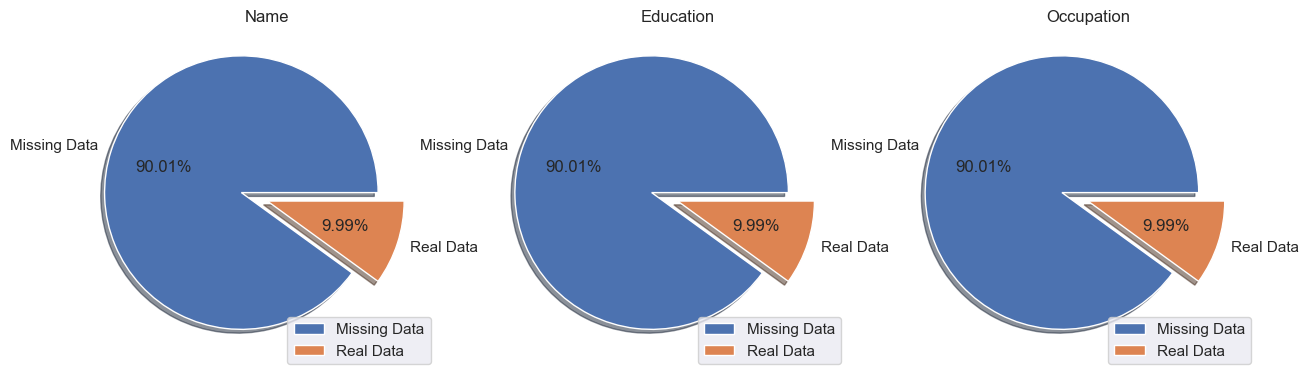

In [38]:
#  Visualization percentage the number of nan values in every featuer have nans

cols = df_sales.isna().sum().loc[df_sales.isna().sum() != 0].index
fig, axes = plt.subplots(1, len(cols), figsize=(5 * len(cols), 5))
for ax, col in zip(axes, cols):
    missing = df_sales[col].isna().sum()
    ax.pie([missing, len(df_sales)-missing] , labels=['Missing Data', 'Real Data'] , shadow=True , explode=[0.2, 0] , autopct='%.2f%%')
    ax.set_title(col)
    ax.legend(wedges, ['Missing Data', 'Real Data'])

In [48]:
# Ckeck Consistency between Category & Subcategory
df_sales.groupby(['Category', 'Subcategory']).size()

Category                       Subcategory                     
Audio                          Bluetooth Headphones                 3792
                               MP4&MP3                              3527
                               Recording Pen                        1401
Cameras and camcorders         Camcorders                           9472
                               Cameras & Camcorders Accessories     6872
                               Digital Cameras                      8782
                               Digital SLR Cameras                  8832
Cell phones                    Cell phones Accessories             58634
                               Home & Office Phones                 8046
                               Smart phones & PDAs                  6879
                               Touch Screen Phones                  4743
Computers                      Computers Accessories               19658
                               Desktops                     

In [67]:
# Number of duplicates rows
print("Number of duplicates rows is ---->> ", len(df_sales[df_sales.duplicated()].index))

Number of duplicates rows is ---->>  218008


### `Note` : **After dropping the missing data, no duplicate rows were found; therefore, no further duplicate removal was required**

In [23]:
# After dropping the missing data, no duplicate rows were found; therefore, no further duplicate removal was required
test= df_sales.dropna()
len(test[test.duplicated()])

0

In [24]:
# Check duplicates rows
test[test.duplicated()]


,ProductKey,Product Name,Brand,Color,Subcategory,Category,CustomerKey,Customer Code,Name,Education,Occupation,Continent,City,State,CountryRegion,OrderDate,Quantity,Net Price


# --------------------------------------------------------------------------------------------------------------

# EDA Forecast Data

In [5]:
df_forecast = pd.read_json('Data/Raw_data/forecast.json')
df_forecast

,CountryRegion,Brand,Forecast,Year
0,China,A. Datum,201487,2009
1,China,Adventure Works,399490,2009
2,China,Contoso,1173308,2009
3,China,Fabrikam,790074,2009
4,China,Litware,437443,2009
5,China,Northwind Traders,125153,2009
6,China,Proseware,567070,2009
7,China,Southridge Video,161494,2009
8,China,Tailspin Toys,58013,2009
9,China,The Phone Company,192708,2009


In [80]:
# print shape of data
df_forecast.shape

(33, 4)

In [81]:
# Display random answer

df_forecast.sample(1).iloc[0]

CountryRegion    United States
Brand                Proseware
Forecast               2285575
Year                      2009
Name: 28, dtype: object

In [82]:
# Print the general information of the data frame 
df_forecast.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CountryRegion  33 non-null     object
 1   Brand          33 non-null     object
 2   Forecast       33 non-null     int64 
 3   Year           33 non-null     int64 
dtypes: int64(2), object(2)
memory usage: 1.2+ KB


In [84]:
## Unique values and value counts for each categorical feature 
for i in df_forecast.select_dtypes(include=["object"]).columns.tolist():
    print(f"( column_name : {i} )".center(80, " "))
    print("-------------".center(80, " "))
    print(df_forecast[i].value_counts(), "\n")
    print("*" * 66)

                        ( column_name : CountryRegion )                         
                                 -------------                                  
CountryRegion
China            11
Germany          11
United States    11
Name: count, dtype: int64 

******************************************************************
                            ( column_name : Brand )                             
                                 -------------                                  
Brand
A. Datum                3
Adventure Works         3
Contoso                 3
Fabrikam                3
Litware                 3
Northwind Traders       3
Proseware               3
Southridge Video        3
Tailspin Toys           3
The Phone Company       3
Wide World Importers    3
Name: count, dtype: int64 

******************************************************************


In [85]:
# Check Nall
# Missing Values Percentage by Column (%)
(df_forecast.isna().sum() / len(df_forecast)) * 100

CountryRegion    0.0
Brand            0.0
Forecast         0.0
Year             0.0
dtype: float64

In [86]:
# Check number of Nall for each columns
df_forecast.isna().sum().loc[df_forecast.isna().sum()!=0]

Series([], dtype: int64)

In [88]:
# Number of duplicates rows
print("Number of duplicates rows is ---->> ", len(df_forecast[df_forecast.duplicated()].index))

Number of duplicates rows is ---->>  0


In [89]:
# Check duplicates rows
df_forecast[df_forecast.duplicated()]

,CountryRegion,Brand,Forecast,Year


## `Data Quality Assessment`: The forecast dataset was verified to be in perfect condition, exhibiting no missing values or formatting anomalies. Consequently, no preprocessing or transformation pipelines were required for this table